In [1]:
import astropy.constants as acon
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
from numpy.linalg import norm
import astropy.constants as acon
from helper import *

rs = 149600000

def grav(x=149600000):
    '''
    Returns potential at a certain distance from the Sun
    @param x The distance from the Sun, in kilometres.
    '''
    return - acon.G.value * 1e-9 * acon.M_sun.value / rs


/tmp/ipykernel_1171/721141667.py:5: RuntimeWarning: invalid value encountered in sqrt
  u = np.sqrt(v2 - 2*Phi)


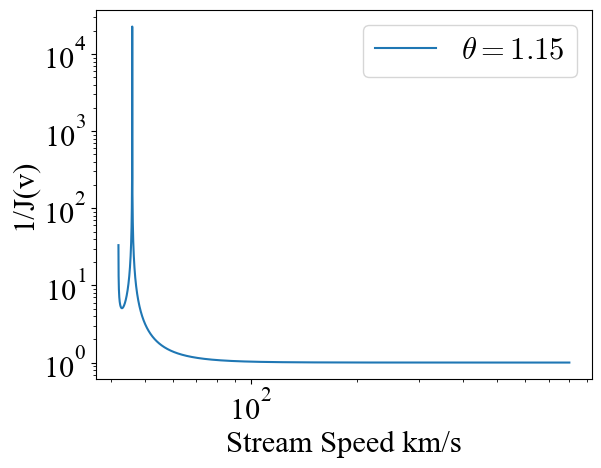

In [7]:
def jacobian_closed_form(v, Phi, theta):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    #v = np.asarray(v, dtype=float)
    v2 = v*v #np.dot(v, v)
    u = np.sqrt(v2 - 2*Phi)
    vdotr = v * np.cos(theta) #np.dot(v, rhat)
    D = u**2 + Phi - u*vdotr
    return np.abs(1 - (Phi/D)**2)


Phi = 887.13
t = 1.152621404201767
v = np.linspace(np.sqrt(2*Phi), 800, 100000)
jac = jacobian_closed_form(v, Phi, t)

plt.clf()
plt.loglog(v, 1/ jac, label = f"$\\theta = {t:.2f}$")

plt.xlabel("Stream Speed km/s")
plt.ylabel("1/J(v)")
plt.legend()


In [23]:
from matplotlib import font_manager

for fontpath in sorted(font_manager.findSystemFonts(fontpaths=None, fontext="ttf")):
    if "FiraSans".lower() in fontpath.lower():
        print(fontpath)

    print(fontpath.lower())

c:\windows\fonts\agencyb.ttf
c:\windows\fonts\agencyr.ttf
c:\windows\fonts\alger.ttf
c:\windows\fonts\antquab.ttf
c:\windows\fonts\antquabi.ttf
c:\windows\fonts\antquai.ttf
c:\windows\fonts\arialn.ttf
c:\windows\fonts\arialnb.ttf
c:\windows\fonts\arialnbi.ttf
c:\windows\fonts\arialni.ttf
c:\windows\fonts\arlrdbd.ttf
c:\windows\fonts\baskvill.ttf
c:\windows\fonts\bauhs93.ttf
c:\windows\fonts\bell.ttf
c:\windows\fonts\bellb.ttf
c:\windows\fonts\belli.ttf
c:\windows\fonts\bernhc.ttf
c:\windows\fonts\bkant.ttf
c:\windows\fonts\bod_b.ttf
c:\windows\fonts\bod_bi.ttf
c:\windows\fonts\bod_blai.ttf
c:\windows\fonts\bod_blar.ttf
c:\windows\fonts\bod_cb.ttf
c:\windows\fonts\bod_cbi.ttf
c:\windows\fonts\bod_ci.ttf
c:\windows\fonts\bod_cr.ttf
c:\windows\fonts\bod_i.ttf
c:\windows\fonts\bod_pstc.ttf
c:\windows\fonts\bod_r.ttf
c:\windows\fonts\bookos.ttf
c:\windows\fonts\bookosb.ttf
c:\windows\fonts\bookosbi.ttf
c:\windows\fonts\bookosi.ttf
c:\windows\fonts\bradhitc.ttf
c:\windows\fonts\britanic.ttf


In [43]:

for fontpath in set(font_manager.fontManager.ttflist):
    print(fontpath.name)

Agency FB
Bodoni MT
Calibri
Lucida Calligraphy
Franklin Gothic Medium Cond
Tw Cen MT Condensed
Segoe UI
Javanese Text
Wingdings
Cambria
Broadway
Gloucester MT Extra Condensed
Webdings
cmss10
Leelawadee
Yu Gothic
Dubai
Times New Roman
Gabriola
Arial
DejaVu Serif
Stencil
Gill Sans MT
Harrington
Franklin Gothic Book
Felix Titling
Lucida Bright
Rockwell Extra Bold
Goudy Old Style
Sitka
Leelawadee UI
Segoe Script
Vivaldi
Consolas
Arial
DejaVu Serif
Microsoft YaHei
Bookman Old Style
Showcard Gothic
Gill Sans MT
Century Gothic
Bauhaus 93
Franklin Gothic Book
Calisto MT
Symbol
Segoe UI
Malgun Gothic
Bodoni MT
MS Outlook
Rockwell
Comic Sans MS
Script MT Bold
Bodoni MT
Verdana
Century Schoolbook
Segoe Print
Franklin Gothic Medium
French Script MT
Tw Cen MT
Snap ITC
Vladimir Script
Microsoft Uighur
Lucida Bright
High Tower Text
Bookman Old Style
Elephant
Garamond
Gill Sans MT Condensed
Nirmala UI
Cambria
MS Gothic
Candara
MingLiU-ExtB
Consolas
Times New Roman
Wingdings 3
Rockwell Condensed
Lucida

In [44]:
import matplotlib
#from pyfonts import load_google_font

font = {'family' : 'Garamond',
        'weight' : 'normal',
        'size'   : 22}
#matplotlib.rcParams['font.serif'] = "Times New Roman"
matplotlib.rcParams["mathtext.fontset"] = "cm"

matplotlib.rc('font', **font)

SMALL_SIZE = 19
MEDIUM_SIZE = 25
BIGGER_SIZE = 27

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

<Figure size 640x480 with 0 Axes>

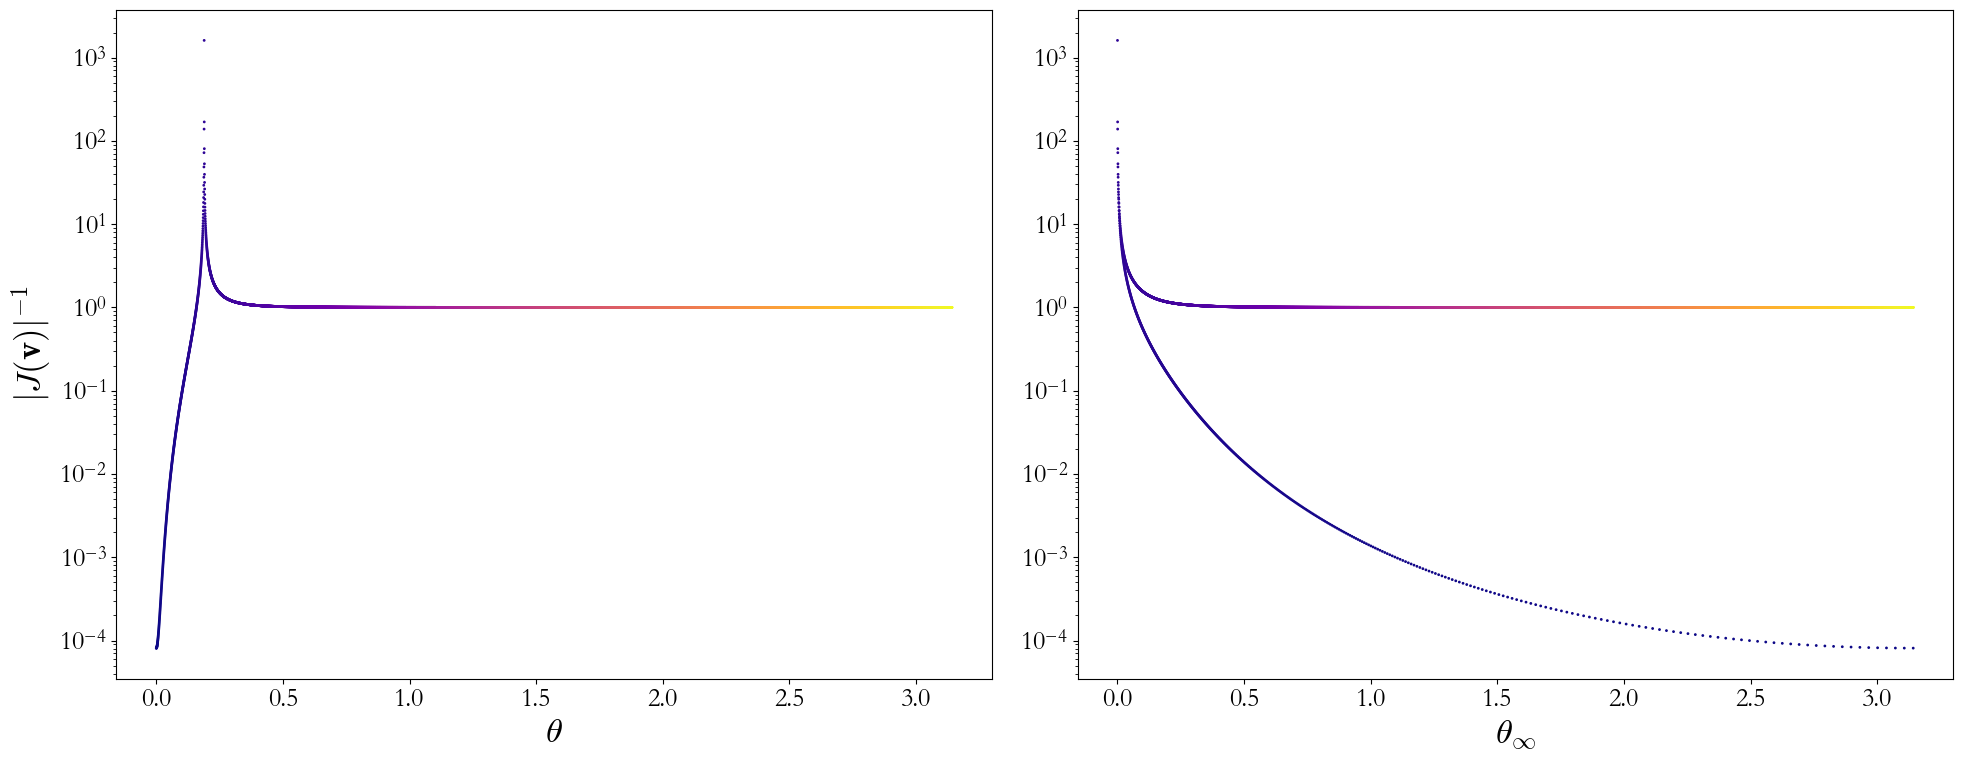

In [290]:
def jacobian_closed_form(v, Phi, theta):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    #v = np.asarray(v, dtype=float)
    v2 = v * v #np.sum(v * v, axis = 1) #np.dot(v, v)
    u = np.sqrt(v2 - 2*Phi)
    vdotr = v * np.cos(theta) #np.dot(v, rhat)
    D = u**2 + Phi - u*vdotr
    return np.abs(1 - (Phi/D)**2)

Phi = -grav(1)
#t = np.linspace(0, 1 * np.pi, 10000)
spd = 220#np.sqrt(Phi*2)
spd_loc = np.sqrt(2*Phi + spd*spd) #np.linspace(np.sqrt(2*Phi), 500, 1000)
z_vel = 0
r = np.array([1, 0, 0])

def v_inf(v, theta):
    #r = np.array([-1/sqrt(2), 1/sqrt(2), 0])
    d = np.sqrt(v*v + 2 * grav(r))

    vhat = np.array([np.cos(theta), np.sin(theta), z_vel])
    vhat = vhat / np.linalg.norm(vhat)

    vi = d * d * v * vhat\
        -  d * r / 1 * grav(r) \
        - d * v * vhat * (v * np.cos(theta))
    
    vi = vi / (d*d - grav(r) - d * v * np.cos(theta))
    
    return vi

v_i = []
phi = np.linspace(0, np.pi, 10000)
#phi1 = np.linspace(0, 1.1274289298939966, 2500)
#phi2 = np.linspace(1.1274289298939966, np.pi, 2500)
#phi = np.append(phi1, phi2)

for t in phi:
    v_i.append(v_inf(spd_loc, t))

v_i = np.array(v_i)

v = np.column_stack([np.cos(phi), np.sin(phi), np.zeros_like(phi) + z_vel])
phi = np.sum(v * r, axis=1) / np.sqrt(np.sum(v*v, axis = 1))
phi = np.arccos(phi)


ang1 = np.sum(v_i * r, axis=1) / np.sqrt(np.sum(v_i*v_i, axis = 1))
ang = np.arccos(ang1)
#ang[ang1 < 0] = -ang[ang1 < 0]
#ang[100:] = -ang[100:]


#v = np.sqrt(2 * Phi / 10 * 16 + 2*Phi)
jac = jacobian_closed_form(spd_loc, Phi, phi)


ind = np.argmin(jac)


plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

ax[0].semilogy()
ax[0].scatter(phi, 1/jac, s= 1, c = np.arange(0, len(ang), 1), cmap= "plasma")
ax[0].set_xlabel(r"$\theta$")
ax[0].set_ylabel("$|J(\\mathbf{v})|^{-1}$")

ax[1].semilogy()
ax[1].scatter(ang, 1/jac, s= 1, c = np.arange(0, len(ang), 1), cmap="plasma")
ax[1].set_xlabel(r"$\theta_\infty$")
#ax[1].set_ylabel("$|J(\\mathbf{v})|^{-1}$")

fig.tight_layout()
fig.savefig("plots/densitydiff.png", bbox_inches ="tight", dpi=500)

<Figure size 640x480 with 0 Axes>

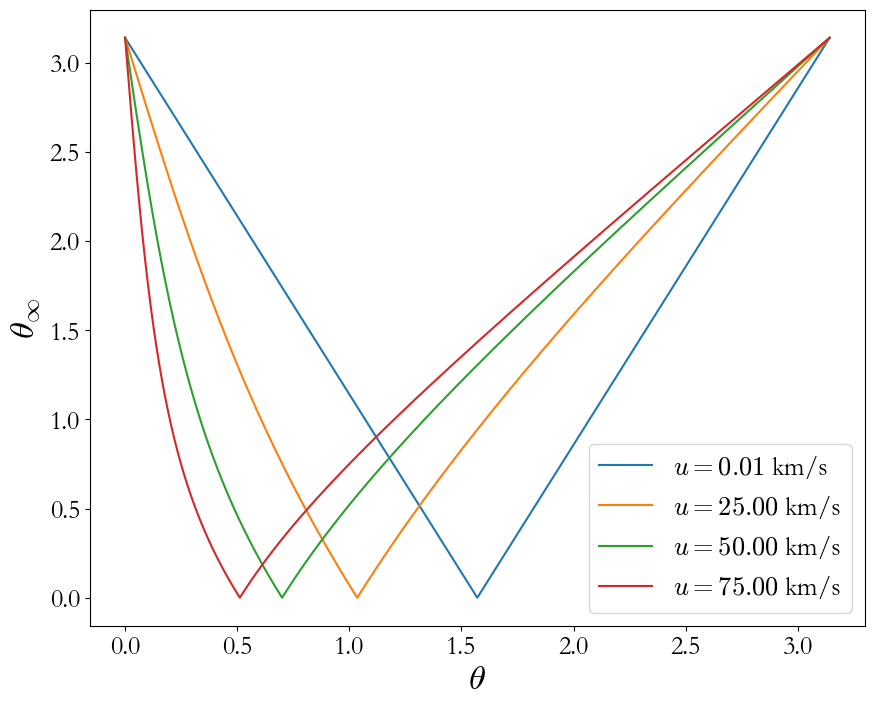

In [289]:
def jacobian_closed_form(v, Phi, theta):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    #v = np.asarray(v, dtype=float)
    v2 = v * v #np.sum(v * v, axis = 1) #np.dot(v, v)
    u = np.sqrt(v2 - 2*Phi)
    vdotr = v * np.cos(theta) #np.dot(v, rhat)
    D = u**2 + Phi - u*vdotr
    return np.abs(1 - (Phi/D)**2)

def v_inf(v, theta):
    #r = np.array([-1/sqrt(2), 1/sqrt(2), 0])
    d = np.sqrt(v*v + 2 * grav(r))

    vhat = np.array([np.cos(theta), np.sin(theta), z_vel])
    vhat = vhat / np.linalg.norm(vhat)

    vi = d * d * v * vhat\
        -  d * r / 1 * grav(r) \
        - d * v * vhat * (v * np.cos(theta))
    
    vi = vi / (d*d - grav(r) - d * v * np.cos(theta))
    
    return vi

Phi = -grav(1)

us = [0.01, 25, 50, 75]#np.linspace(0., 100, 4)
plt.clf()
plt.figure(figsize=(10,8))

for spd in us:
#spd = np.sqrt(Phi*2)
    spd_loc = np.sqrt(2*Phi + spd*spd) #np.linspace(np.sqrt(2*Phi), 500, 1000)
    z_vel = 0
    r = np.array([1, 0, 0])

    v_i = []
    phi = np.linspace(0, np.pi, 5000)

    for t in phi:
        v_i.append(v_inf(spd_loc, t))

    v_i = np.array(v_i)

    v = np.column_stack([np.cos(phi), np.sin(phi), np.zeros_like(phi) + z_vel])
    phi = np.sum(v * r, axis=1) / np.sqrt(np.sum(v*v, axis = 1))
    phi = np.arccos(phi)


    ang1 = np.sum(v_i * r, axis=1) / np.sqrt(np.sum(v_i*v_i, axis = 1))
    ang = np.arccos(ang1)

    plt.plot(phi, ang, label=f"$u = {spd:.2f}$ km/s")

plt.xlabel("$\\theta$")
plt.ylabel("$\\theta_\\infty$")

plt.legend()

plt.savefig("plots/incident_angle.png", bbox_inches ="tight", dpi=300)
#jac = jacobian_closed_form(spd_loc, Phi, phi)

<Figure size 640x480 with 0 Axes>

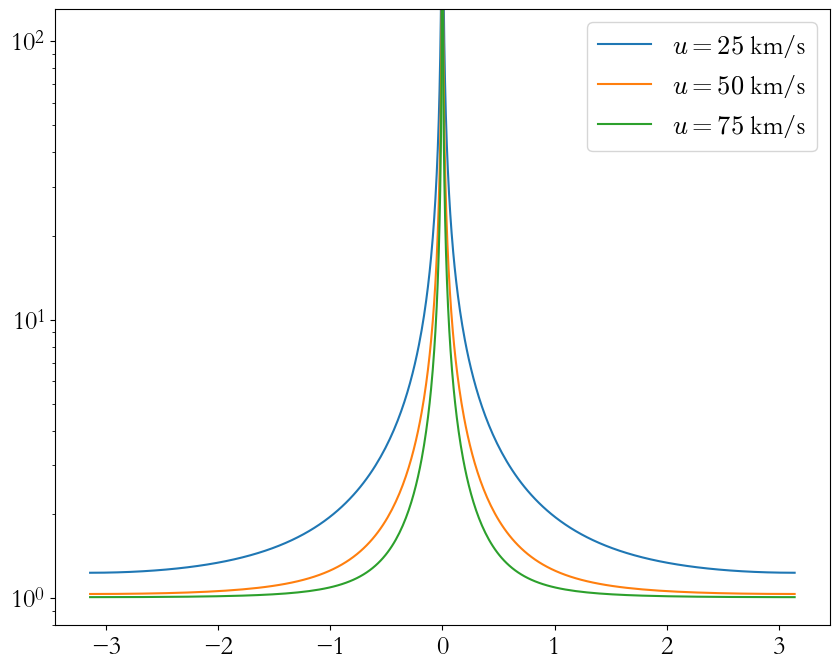

In [326]:
from scipy.optimize import minimize

def jacobian_closed_form(v, Phi, theta):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    #v = np.asarray(v, dtype=float)
    v2 = v * v #np.sum(v * v, axis = 1) #np.dot(v, v)
    u = np.sqrt(v2 - 2*Phi)
    vdotr = v * np.cos(theta) #np.dot(v, rhat)
    D = u**2 + Phi - u*vdotr
    return np.abs(1 - (Phi/D)**2)

def theta_inf(theta, u, Phi):
    v = np.sqrt(u*u + 2 * Phi)
    numer = v * np.sin(theta) * (u - v * np.cos(theta))
    denom = u * v * np.cos(theta) - (v*np.cos(theta))**2 + Phi
    tan = numer/denom
    
    angle = np.arctan(tan)
    if angle < 0:
        angle = np.pi + angle
        
    return angle

def func(theta, u, Phi, thetainf):
    return np.abs(theta_inf(theta, u, Phi) - thetainf)

plt.clf()
plt.figure(figsize=(10, 8))

phi = np.linspace(0, np.pi - 1, 100)[:-1]
phi = np.logspace(-3, np.log10(np.pi), 200)

Phi = -grav()

c = ["tab:blue", "tab:orange", "tab:green"]
i = 0
for spd in [25, 50, 75]:
    spd_loc = np.sqrt(2*Phi + spd*spd)

    #phi = [0.05235987755982974]
    #phi = [np.pi/2]

    dens = []
    for p in phi:
        ang1 = minimize(func, x0 = np.arccos(spd/spd_loc), bounds = [(np.arccos(spd/spd_loc), np.pi)], args=(spd, -grav(), p)).x[0]
        ang2 = minimize(func, x0 = 0, bounds = [(0,np.arccos(spd/spd_loc))], args=(spd, -grav(), np.pi - p)).x[0]
        
        assert func(ang1, spd, Phi, p) < 1e-7
        assert func(ang2, spd, Phi, np.pi - p) < 1e-7
        
        den = 1 / jacobian_closed_form(spd_loc, Phi, ang1) + 1 / jacobian_closed_form(spd_loc, Phi, ang2)
        dens.append(den)

    plt.semilogy(phi[1:], dens[1:], c = c[i], label = f"$u = {spd}$ km/s")
    plt.semilogy(-phi[1:][::-1], dens[1:][::-1], c = c[i])
    i+=1

plt.ylim((0.8, 130))
plt.legend()

In [307]:
func(ang1, spd, Phi, p)

np.float64(135.4039804831113)

In [284]:
dens[-1]

np.float64(23.003611094040437)

In [216]:
phi

[0.15707963267948966]

The reason i think we get two "curves" in the case of the second plot (where we plot the angle between the original stream velocity and position of earth), is due to the fact we are solving this in 3 dimensions. The stream itself will be a 2d plane wave of particles, and so the intersection between this plane wave and the plane of the earth's orbit will get boosted alot more. If we consider the plane of the earths orbit to be in x and y, then particles with a non-zero z position will be limited alot more in their position if their trajectories coincide with the earth's position. However, if the earths position is directly in line with the plane velocity then it doesn't matter as the particles with non-zero z will get boosted the same as particles purely in x-y plane. 

I.e., the actual density should be the two curves added on to each other. Furthermore, since we are only considering angles from 0 to pi, due to symmetry arguments, the density should be twice this? (actually not sure about the latter part) 

In [ ]:
def grav(x):
    return - acon.G.value * 1e-9 * acon.M_sun.value / 149600000

def v_inf(v, phi):
    r = np.array([[np.cos(phi), np.sin(phi), np.zeros_like(phi)]]) # in km
    d = np.sqrt(np.sum(v*v) + 2 * grav(r))

    vi = d * d * v \
        -  d * r / speed(r) * grav(r) \
        - d * v * (np.dot(v, r.T / speed(r)))
    
    vi = vi / (d*d - grav(r) - d * np.dot(v, r.T / speed(r)))
    
    return vi

def func(v, vi, phi):
    return (v_inf(v, phi) - vi).T[:, 0]

def jacobian_closed_form(v, Phi, phi):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    v = np.asarray(v, dtype=float)
    #v = v[0]
    rhat = np.array([np.cos(phi), np.sin(phi), np.zeros_like(phi)]).T
    v2 = np.sum(v*v, axis=1)#np.dot(v, v)
    u = np.sqrt(v2 - 2*Phi)
    vdotr = np.sum(v*rhat, axis=1)
    D = u**2 + Phi - u*vdotr
    return (1 - (Phi/D)**2)

phi = np.linspace(-np.pi, np.pi, 1000)
vel = [1, 0, 0]
spd = 60
vel = np.column_stack(vel) #arbritrary speed
vel = spd * vel

v = []
Phi = -grav(1)
for p in phi:
    root = np.array([25, 25, 25])
    x0 = np.array([25, 25, 25])

    i = 0
    ma = 3
    i = 0
    ma = 3
    while ma != -2:
        root = fsolve(func, x0, args=(vel, p))
        
        if np.min(x0 == root) == 0 and jacobian_closed_form([root], Phi, p) > 0:
            break
        
        root = np.array([25, 25, 25])
        if ma <= 0:
            x0 = -x0
            ma -= 1
            continue

        x0[i] = - x0[i]
        
        i += 1
        if i >= ma:
            ma -= 1
            i = 0
        
        root = np.array([25, 25, 25])

    v.append(root)
v = np.array(v)


v1 = []
Phi = -grav(1)
for p in phi:
    root = np.array([25, 25, 25])
    x0 = np.array([25, 25, 25])

    i = 0
    ma = 3
    i = 0
    ma = 3
    while ma != -2:
        root = fsolve(func, x0, args=(vel, p))
        
        if np.min(x0 == root) == 0 and jacobian_closed_form([root], Phi, p) < 0:
            break
        
        root = np.array([25, 25, 25])
        if ma <= 0:
            x0 = -x0
            ma -= 1
            continue

        x0[i] = - x0[i]
        
        i += 1
        if i >= ma:
            ma -= 1
            i = 0
        
        root = np.array([25, 25, 25])

    v1.append(root)
v1 = np.array(v1)

C:\Users\Shaurya\AppData\Local\Temp\ipykernel_9652\2726499519.py:47: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  root = fsolve(func, x0, args=(vel, p))
C:\Users\Shaurya\AppData\Local\Temp\ipykernel_9652\2726499519.py:6: RuntimeWarning: invalid value encountered in sqrt
  d = np.sqrt(np.sum(v*v) + 2 * grav(r))
C:\Users\Shaurya\AppData\Local\Temp\ipykernel_9652\2726499519.py:82: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root = fsolve(func, x0, args=(vel, p))
C:\Users\Shaurya\AppData\Local\Temp\ipykernel_9652\2726499519.py:82: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  root = fsolve(func, x0, args=(vel, p))


In [62]:
jacobian_closed_form(v1, Phi, phi)

array([-9.93274275e+01, -9.93258034e+01, -9.93209313e+01, -9.93128116e+01,
       -9.93014450e+01, -9.92868325e+01, -9.92689754e+01, -9.92478752e+01,
       -9.92235337e+01, -3.61220856e+00, -9.91651359e+01, -9.91310846e+01,
       -2.68546683e+00, -9.90532920e+01, -2.49328967e+00,  5.05375967e-01,
        5.06485620e-01,  5.07583071e-01,  5.08668379e-01,  5.09741601e-01,
        5.10802795e-01,  5.11852016e-01,  5.12889321e-01,  5.13914765e-01,
        5.14928402e-01,  5.15930286e-01,  5.16920471e-01,  5.17899009e-01,
       -1.01757957e-01,  5.19821354e-01,  5.20765264e-01,  5.21697732e-01,
        5.22618809e-01,  5.23528545e-01,  5.24426987e-01,  5.25314185e-01,
        5.26190185e-01,  5.27055034e-01,  5.27908780e-01,  5.28751468e-01,
        5.29583143e-01,  5.30403850e-01,  5.31213633e-01,  5.32012536e-01,
        5.32800602e-01,  5.33577872e-01,  5.34344391e-01,  5.35100197e-01,
        5.35845333e-01,  5.36579838e-01,  5.37303752e-01,  5.38017115e-01,
        5.38719964e-01,  

In [63]:
jacobian_closed_form(v, Phi, phi).max()

np.float64(0.9900326358927183)

Text(0, 0.5, '1/J(v)')

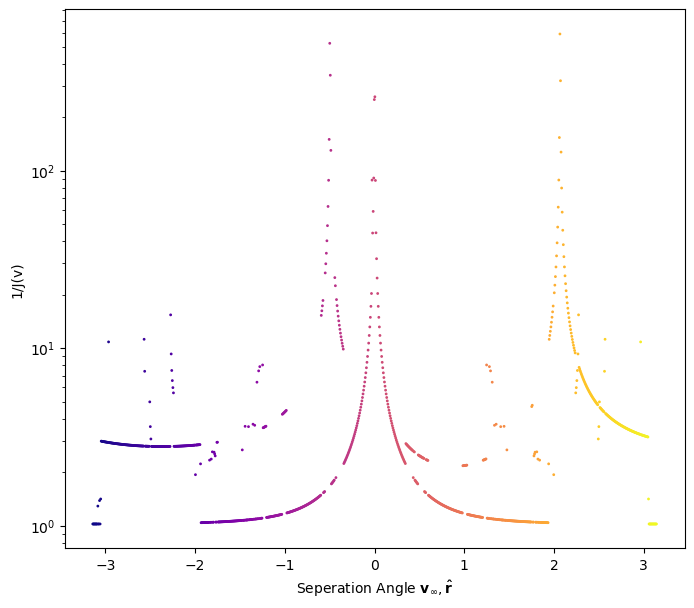

In [64]:
jac = 1 / jacobian_closed_form(v, Phi, phi) + 1 / np.abs(jacobian_closed_form(v1, Phi, phi))
plt.figure(figsize=(8, 7))

plt.semilogy()
plt.scatter(phi, jac, s= 1, c = np.arange(0, len(phi), 1), cmap= "plasma")

plt.xlabel(r"Seperation Angle $\mathbf{v}_\infty, \mathbf{\hat{r}}$")
plt.ylabel("1/J(v)")

In [ ]:
import sympy as sp

v, theta, Phi = sp.symbols('v theta Phi', positive=True, real=True)

# Energy conservation: v_infty (call it u) depends on v alone.
u = sp.sqrt(v**2 - 2*Phi)

# Local velocity components at fixed v, in terms of theta.
v_par  = v*sp.cos(theta)
v_perp = v*sp.sin(theta)

#   v_inf_par  = u*Q/D,   v_inf_perp = u*N/D
# so tan(theta_infty) = N/Q.
Q    = u*v_par - v_par**2 + Phi
N = (u - v_par)*v_perp
D    = u**2 - u*v_par + Phi

tan_theta_inf = N/Q

d_tan_dtheta      = sp.diff(tan_theta_inf, theta)
cos2_theta_inf     = Q**2 / (Q**2 + N**2)
dtheta_inf_dtheta = sp.simplify(cos2_theta_inf * d_tan_dtheta)

identity_check = sp.simplify(Q**2 + N**2 - D**2)
print("Q^2 + N^2 - D^2 (should be 0):", identity_check)

# Confirm the closed form.
target = 1 + Phi/D
print("dtheta_infty/dtheta - (1 + Phi/D):", sp.simplify(dtheta_inf_dtheta - target))

ModuleNotFoundError: No module named 'sympy'

In [8]:
# -----------------------------------------------------------------
# The focusing map v_infty[v], as given in Alenazi & Gondolo (2006)
# / Lee et al. (2014):
#
#   v_infty[v] = [v_inf^2 v + v_inf*Phi*rhat - v_inf*v*(v.rhat)]
#                / [v_inf^2 + Phi - v_inf*(v.rhat)]
#
# with v_inf^2 = |v|^2 - 2*Phi  (energy conservation), and
# Phi = G*M_sun / r.
# -----------------------------------------------------------------

def v_infty_vec(v, Phi, rhat):
    """Evaluate the focusing map for a local velocity vector v."""
    v = np.asarray(v, dtype=float)
    v2 = np.dot(v, v)
    u = np.sqrt(v2 - 2*Phi)          # = v_infty (speed at infinity)
    vdotr = np.dot(v, rhat)
    D = u**2 + Phi - u*vdotr
    return (u**2*v + u*Phi*rhat - u*v*vdotr) / D


def jacobian_finite_difference(v, Phi, rhat, h=1e-5):
    """Full 3x3 Cartesian Jacobian of v_infty_vec at v, via central
    finite differences (more accurate than forward differences,
    and cheap enough here that there's no reason not to use it)."""
    J = np.zeros((3, 3))
    for i in range(3):
        dv = np.zeros(3)
        dv[i] = h
        plus = v_infty_vec(v + dv, Phi, rhat)
        minus = v_infty_vec(v - dv, Phi, rhat)
        J[:, i] = (plus - minus) / (2*h)
    return J


def jacobian_closed_form(v, Phi, rhat):
    """The derived closed-form result: |dv_infty/dv| = 1 - (Phi/D)^2."""
    v = np.asarray(v, dtype=float)
    v2 = np.dot(v, v)
    u = np.sqrt(v2 - 2*Phi)
    vdotr = np.dot(v, rhat)
    D = u**2 + Phi - u*vdotr
    return np.abs(1 - (Phi/D)**2)


# -----------------------------------------------------------------
# Run the check at several random test points, at a fixed field
# point (r = 1 AU, so Phi = GM_sun/r ~ 887 km^2/s^2), with a
# few different orientations of rhat to make sure nothing was
# accidentally special about a particular choice of axis.
# -----------------------------------------------------------------
if __name__ == "__main__":
    Phi = 887.13   # km^2/s^2, GM_sun/r at 1 AU

    rng = np.random.default_rng(seed=42)
    print(f"{'v (km/s)':>28}   {'rhat':>20}   {'FD Jacobian':>12}   {'Closed form':>12}   {'rel. error':>10}")
    print("-"*100)

    err = []
    jac = []

    n_checks = 1000
    for _ in range(n_checks):
        # random rhat direction (unit vector)
        rhat = rng.normal(size=3)
        rhat /= np.linalg.norm(rhat)

        # random local velocity, large enough in magnitude that
        # v^2 > 2*Phi (unbound orbit) is guaranteed
        v = rng.normal(scale=150, size=3)
        v += rhat * 250   # bias towards a physically sensible speed
        if np.dot(v, v) <= 2*Phi:
            continue

        J_fd = jacobian_finite_difference(v, Phi, rhat, h=1e-5)
        detJ_fd = np.abs(np.linalg.det(J_fd))
        J_closed = jacobian_closed_form(v, Phi, rhat)

        rel_err = abs(detJ_fd - J_closed) / abs(J_closed)

        err.append(rel_err)
        jac.append((J_closed, detJ_fd))

        v_str = np.array2string(v, precision=1, suppress_small=True)
        r_str = np.array2string(rhat, precision=2, suppress_small=True)
        print(f"{v_str:>28}   {r_str:>20}   {detJ_fd:12.8f}   {J_closed:12.8f}   {rel_err:10.2e}")

    print("\nIf the relative errors above are all ~1e-8 or smaller, the closed form is confirmed.")

                    v (km/s)                   rhat    FD Jacobian    Closed form   rel. error
----------------------------------------------------------------------------------------------------
      [ 198.9 -489.9  -53. ]    [ 0.23 -0.79  0.57]     0.99983164     0.99983163     1.12e-08
         [-34.4 -99.6 104.4]    [ 0.37 -0.93 -0.05]     0.99293257     0.99293257     1.11e-10
      [-115.4  285.9  -48.2]       [0.05 0.92 0.38]     0.99845669     0.99845668     8.36e-09
         [142.1 169.5 -74.6]    [ 0.98 -0.06 -0.21]     0.99810169     0.99810169     2.07e-10
         [-84.5 -52.6 237.8]    [-0.56 -0.46  0.69]     0.97469507     0.97469508     1.15e-08
         [117.   47.  112.2]    [ 0.96 -0.18 -0.23]     0.99645223     0.99645223     2.56e-09
         [ 73.5 -66.1 -92.8]    [-0.1  -0.71 -0.7 ]     0.95128858     0.95128858     5.64e-09
      [-200.1  212.    74.4]    [-0.93  0.32  0.16]     0.99205994     0.99205993     1.26e-08
      [ 323.7 -195.8   49.6]       [0.92 0.0